In [173]:
!pip install yfinance --upgrade

  Using cached yfinance-1.4.0-py2.py3-none-any.whl.metadata (6.2 kB)
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached yfinance-1.2.2-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached yfinance-1.2.1-py2.py3-none-any.whl.metadata (6.1 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [174]:
import yfinance 
import pandas as pd
data = yfinance.download("AAPL",start="2015-01-01",end="2023-01-01")
print(data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2015-01-02   24.192604   24.659506   23.754468   24.648441  212818400
2015-01-05   23.511061   24.042134   23.325186   23.962473  257142000
2015-01-06   23.513271   23.772169   23.152583   23.575230  263188400
2015-01-07   23.842981   23.942557   23.610636   23.721276  160423600
2015-01-08   24.759081   24.816614   24.053195   24.170475  237458000
...                ...         ...         ...         ...        ...
2022-12-23  129.659409  130.210060  127.476457  128.735094   63814900
2022-12-27  127.859932  129.216906  126.571797  129.187408   69007800
2022-12-28  123.936523  128.843243  123.769362  127.505940   85438400
2022-12-29  127.446938  128.302413  125.598316  125.853971   75703700
2022-12-30  127.761597  127.781267  125.303327  126.266975   77034200

[2014 rows x 5 colu

In [175]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

minmax = MinMaxScaler()
scaleddata = minmax.fit_transform(data["High"])
print(scaleddata)

[[0.02399578]
 [0.02008788]
 [0.01837903]
 ...
 [0.68346881]
 [0.68004541]
 [0.6767466 ]]


In [176]:
seqLen = 60
X = []
y = []
for pos in range(len(scaleddata)-seqLen): 
    X.append(scaleddata[pos:pos+seqLen])
    y.append(scaleddata[pos+seqLen])

X = np.array(X)
y = np.array(y)
print(X[0])
print(y[0])

[[0.02399578]
 [0.02008788]
 [0.01837903]
 [0.01945757]
 [0.02499026]
 [0.02653101]
 [0.02566261]
 [0.02590074]
 [0.02266513]
 [0.02206284]
 [0.01858915]
 [0.02053613]
 [0.0234635 ]
 [0.0254385 ]
 [0.02723136]
 [0.02808579]
 [0.02545249]
 [0.03335241]
 [0.03485109]
 [0.03598568]
 [0.03482306]
 [0.03471099]
 [0.03670005]
 [0.03697242]
 [0.03700058]
 [0.03642399]
 [0.03967237]
 [0.04356753]
 [0.04716745]
 [0.04688622]
 [0.04913614]
 [0.04899552]
 [0.04934712]
 [0.05000802]
 [0.05492981]
 [0.05577347]
 [0.05296109]
 [0.05193451]
 [0.05151268]
 [0.05110483]
 [0.05003615]
 [0.05009238]
 [0.04895336]
 [0.04982522]
 [0.05010647]
 [0.04680188]
 [0.04335664]
 [0.04353943]
 [0.04424258]
 [0.04360976]
 [0.0469425 ]
 [0.0495299 ]
 [0.04965648]
 [0.04846117]
 [0.04768776]
 [0.04795494]
 [0.04623935]
 [0.04351128]
 [0.04325816]
 [0.04564873]]
[0.04577533]


In [177]:
print(X.shape)

(1954, 60, 1)


In [178]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

model = Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=X.shape[1:]))
model.add(Dropout(0.2))
model.add(LSTM(units=50,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mean_squared_error")

In [179]:
'''from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=1)'''

'from sklearn.model_selection import train_test_split\n\nXtrain,Xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=1)'

In [180]:
trainSize = int(len(X)*0.8)
Xtrain = X[0:trainSize]
Xtest = X[trainSize:]
ytrain = y[0:trainSize]
ytest = y[trainSize:]

In [181]:
model.fit(Xtrain,ytrain,epochs=50,batch_size=32,validation_data=(Xtest,ytest))

Epoch 1/50
49/49 [==============================] - 3s 26ms/step - loss: 0.0084 - val_loss: 0.0018
Epoch 2/50
49/49 [==============================] - 1s 19ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 3/50
49/49 [==============================] - 1s 19ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 4/50
49/49 [==============================] - 1s 19ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 5/50
49/49 [==============================] - 1s 21ms/step - loss: 9.9759e-04 - val_loss: 0.0027
Epoch 6/50
49/49 [==============================] - 1s 22ms/step - loss: 0.0011 - val_loss: 0.0033
Epoch 7/50
49/49 [==============================] - 1s 23ms/step - loss: 9.8362e-04 - val_loss: 0.0016
Epoch 8/50
49/49 [==============================] - 1s 22ms/step - loss: 8.6342e-04 - val_loss: 0.0015
Epoch 9/50
49/49 [==============================] - 1s 22ms/step - loss: 7.6719e-04 - val_loss: 0.0034
Epoch 10/50
49/49 [==============================] - 1s 22ms/step - loss: 7.6164e-04 - val_lo

In [182]:
pred = model.predict(Xtest)
newPred = minmax.inverse_transform(pred).reshape(-1,1)
newytest = minmax.inverse_transform(ytest).reshape(-1,1)
print(newPred[0:10])
print(newytest[0:10])

13/13 [==============================] - 1s 8ms/step
[[122.96091 ]
 [123.60385 ]
 [124.23066 ]
 [124.98079 ]
 [125.534485]
 [126.03326 ]
 [126.647675]
 [127.25218 ]
 [127.804375]
 [128.14333 ]]
[[127.30262798]
 [127.58528206]
 [129.20340664]
 [128.18963066]
 [129.06689432]
 [130.69474066]
 [130.92869718]
 [131.24058179]
 [130.50952707]
 [131.83517921]]


In [183]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(newytest,newPred)
mse = mean_squared_error(newytest,newPred)
print(mae)
print(mse)

5.238968624931101
39.48468903412939


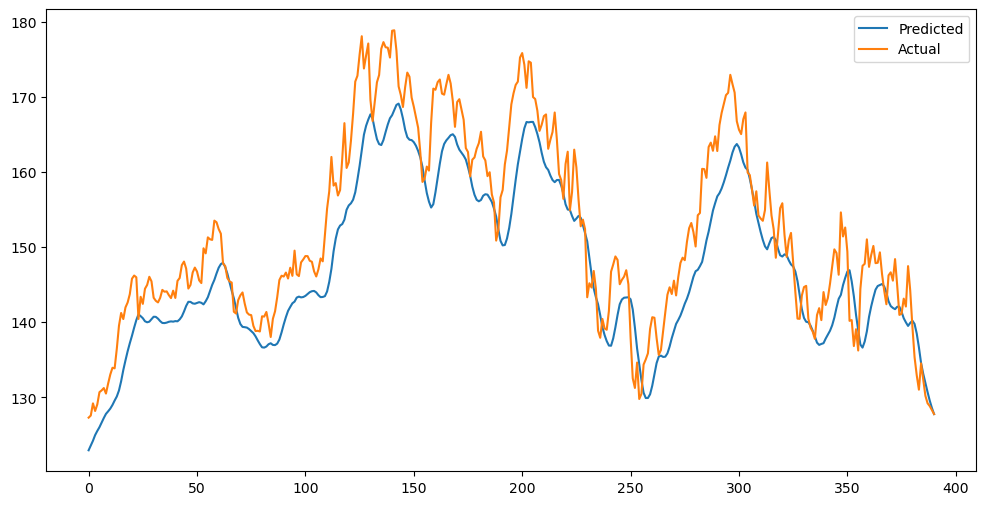

In [184]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(newPred,label="Predicted")
plt.plot(newytest,label="Actual")

plt.legend()
plt.show()

In [185]:
''' 
Apple : 
mae - 3.4240175720370942
mse - 19.474783583215938
'''

' \nApple : \nmae - 3.4240175720370942\nmse - 19.474783583215938\n'